# Autogen API Overview

- This notebook shows the working of autogen API and all its individual components and its explanations.

In [1]:
# Standard Library Imports.
import os
import io

# Third-Party Libraries.
import requests
import PIL.Image
import IPython.display

# Autogen Core & Utilities.
import autogen_core
from autogen_core.models import UserMessage
import autogen_core.tools as tools  # FunctionTool.

# Autogen Extensions / Models.
# For OpenAIChatCompletionClient.
import autogen_ext.models.openai as openai

# Autogen AgentChat Modules.
import autogen_agentchat
import autogen_agentchat.teams as teams
# For AssistantAgent.
import autogen_agentchat.agents as agent
# For Message and Event types.
import autogen_agentchat.messages as msg
# For TaskResult.
import autogen_agentchat.base as base
import autogen_agentchat.ui as ui
import autogen_agentchat.conditions as conditions

## Agents

### Assistant Agent
- AssistantAgent is a built-in agent that uses a language model and has the ability to use tools.
- The below cell shows how to implement the agent.

In [2]:
async def web_search(query: str) -> str:
    """
    Find information on the web.
    """
    return "AutoGen is a programming framework for building multi-agent applications."


assert os.environ.get("OPENAI_API_KEY", None) is not None

# Create an agent that uses the OpenAI GPT-4o model.
openai_model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4.1-nano",
    api_key=os.environ["OPENAI_API_KEY"],
)
autogen_agentchat = agent.AssistantAgent(
    name="assistant",
    model_client=openai_model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

The **cell below** sends a user message to the OpenAI model client and prints the model’s response.

In [3]:
result = await openai_model_client.create(
    [UserMessage(content="What is the capital of France?", source="user")]
)
print(result)

finish_reason='stop' content='The capital of France is Paris.' usage=RequestUsage(prompt_tokens=15, completion_tokens=7) cached=False logprobs=None thought=None


### Multi-Modal Input
- The AssistantAgent can handle multi-modal input by providing the input as a MultiModalMessage as shown below


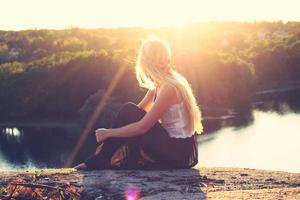

In [4]:
# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(
    io.BytesIO(requests.get("https://picsum.photos/300/200").content)
)
img = autogen_core.Image(pil_image)
multi_modal_message = msg.MultiModalMessage(
    content=["Can you describe the content of this image?", img], source="user"
)
img

### Streaming Messages
- Streaming each message can be done using the `run_stream()` method and use Console to print the messages as they appear to the console as shown in the below cell.

In [5]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await ui.Console(
        autogen_agentchat.run_stream(task="Find information on AutoGen"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()

---------- TextMessage (user) ----------
Find information on AutoGen
---------- ToolCallRequestEvent (assistant) ----------
[FunctionCall(id='call_4Q2vDVvsdEhalcIc4tofzaa2', arguments='{"query":"AutoGen"}', name='web_search')]
[Prompt tokens: 61, Completion tokens: 15]
---------- ToolCallExecutionEvent (assistant) ----------
[FunctionExecutionResult(content='AutoGen is a programming framework for building multi-agent applications.', name='web_search', call_id='call_4Q2vDVvsdEhalcIc4tofzaa2', is_error=False)]
---------- ToolCallSummaryMessage (assistant) ----------
AutoGen is a programming framework for building multi-agent applications.
---------- Summary ----------
Number of messages: 4
Finish reason: None
Total prompt tokens: 61
Total completion tokens: 15
Duration: 0.34 seconds


### Function Tool
- The web_search_func tool is an example of a function tool. The schema is automatically generated.
- The cell below shows its working

In [6]:
# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """
    Find information on the web.
    """
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = tools.FunctionTool(
    web_search_func, description="Find information on the web"
)
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema

{'name': 'web_search_func',
 'description': 'Find information on the web',
 'parameters': {'type': 'object',
  'properties': {'query': {'description': 'query',
    'title': 'Query',
    'type': 'string'}},
  'required': ['query'],
  'additionalProperties': False},
 'strict': False}

### Parallel Tool Calls
Some models can call multiple tools simultaneously. By default, `AssistantAgent` executes parallel tool calls if the model client produces them.

> **Caution:** Disable parallel tool calls when tools have side effects or when consistent agent behavior is required. This is configured at the model client level.

**Important:**
- `AgentTool` and `TeamTool` **must not** run in parallel due to internal state conflicts.
- For `OpenAIChatCompletionClient` and `AzureOpenAIChatCompletionClient`, set `parallel_tool_calls=False` to disable parallel execution.

In [7]:
model_client_no_parallel_tool_call = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    parallel_tool_calls=False,  # type: ignore
    api_key=os.environ["OPENAI_API_KEY"],
)
agent_no_parallel_tool_call = agent.AssistantAgent(
    name="assistant",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

### Tool Iterations
- One model call followed by one tool call or parallel tool calls is a single tool iteration. By default, the AssistantAgent will execute at most one iteration.

In [8]:
agent_loop = agent.AssistantAgent(
    name="assistant_loop",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
    max_tool_iterations=10,  # At most 10 iterations of tool calls before stopping the loop.
)

### Streaming Tokens
- You can stream the tokens generated by the model client by setting model_client_stream=True. This will cause the agent to yield ModelClientStreamingChunkEvent messages in run_stream() as shown in the below cell.
- You can see the streaming chunks in the output above. The chunks are generated by the model client and are yielded by the agent as they are received. The final response, the concatenation of all the chunks, is yielded right after the last chunk in the output in the cell below

In [9]:
streaming_assistant = agent.AssistantAgent(
    name="assistant",
    model_client=openai_model_client,
    system_message="You are a helpful assistant.",
    model_client_stream=True,  # Enable streaming tokens.
)

# Use an async function and asyncio.run() in a script.
async for message in streaming_assistant.run_stream(
    task="Name two cities in South America"
):  # type: ignore
    print(message)

id='e0ff053e-115b-4ad8-81a6-e12c3060475d' source='user' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 21, 21, 36, 37, 501695, tzinfo=datetime.timezone.utc) content='Name two cities in South America' type='TextMessage'
id='7d8850ea-0651-4f9f-9e1f-ff0406ef77bb' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 21, 21, 36, 37, 804430, tzinfo=datetime.timezone.utc) content='Sure' full_message_id='07e11714-a51b-4f6c-8300-8a4e29c5f883' type='ModelClientStreamingChunkEvent'
id='08e316f5-ce1e-46e7-891a-5ac23b958c9f' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 21, 21, 36, 37, 804905, tzinfo=datetime.timezone.utc) content='!' full_message_id='07e11714-a51b-4f6c-8300-8a4e29c5f883' type='ModelClientStreamingChunkEvent'
id='36085043-99af-4d39-a1a9-c3272ccedeef' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 21, 21, 36, 37, 814936, tzinfo=datetime.timezone.utc

## Messages
There are primarily 2 types of messages in autogen:
- Agent-Agent Messages
- Agent's Internal Events

### The below cell shows the working of Agent to Agent communication.

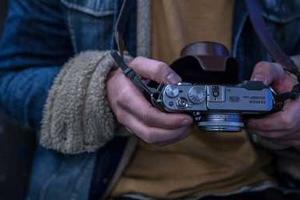


--- Message from User ---
['Look at this camera feed and discuss it.', <autogen_core._image.Image object at 0xffff65985610>]

--- Message from Vision_Specialist ---
The camera feed shows a person holding a digital camera, with all focus on the hands and the camera itself. The individual appears to be wearing a warm, fuzzy glove on one hand, possibly indicating cold weather. The camera is being operated with both hands, suggesting the person might be preparing to take a photo or adjust settings. The background shows part of a jacket and some straps, hinting at an outdoor or casual setting. Without additional context, it's difficult to determine what exactly they are photographing or the surrounding environment.

--- Message from Reviewer ---
A creative use for this scene could be to capture a storytelling photo series highlighting outdoor exploration or adventurous activities in colder environments. Focusing on the hands, the camera, and the surrounding winter gear can evoke a sense of

In [10]:
# 1. Setup the Model Client (using existing openai_model_client from previous step).
# 2. Define Agent A: The Vision Specialist.
vision_agent = agent.AssistantAgent(
    name="Vision_Specialist",
    model_client=openai_model_client,
    system_message="Describe the image provided in detail.",
)
# 3. Define Agent B: The Reviewer.
reviewer_agent = agent.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="Based on the description provided, suggest one creative use for this item.",
)
# 4. Create the Team (this enables true Agent-to-Agent communication).
agent_team = teams.RoundRobinGroupChat(
    [vision_agent, reviewer_agent], max_turns=2
)
# 5. Prepare the MultiModalMessage from your local file.
pil_image = PIL.Image.open("artifacts/camera.png")
img = autogen_core.Image(pil_image)
IPython.display.display(pil_image)
input_message = msg.MultiModalMessage(
    content=["Look at this camera feed and discuss it.", img], source="User"
)
# 6. Run the Team.
# The team will pass the MultiModalMessage from the User to Agent A,
# then Agent A's response to Agent B automatically.
async for message in agent_team.run_stream(task=input_message):
    # TaskResult objects don't have 'source', so we check if 'source' exists.
    if hasattr(message, "source"):
        print(f"\n--- Message from {message.source} ---")
        print(message.content)
    else:
        # This handles the final TaskResult object.
        print("\n--- Task Complete ---")
        # Optional: print(message.stop_reason)

### Agent's Internal Events
- In the below example, the agent does not show reasoning because the question is a simple factual lookup, and the model directly produces the answer without generating visible step-by-step reasoning.

In [11]:
async def internal_events():
    # 1. Setup the agent using the 'agent' alias.
    # model_client_stream=True is required to see the internal 'Thinking' events.
    solo_agent = agent.AssistantAgent(
        name="Solo_Assistant",
        model_client=openai_model_client,
        system_message="You are a helpful assistant.",
        model_client_stream=True,
    )
    print("--- Execution Started ---\n")
    # 2. Process the stream using the 'msg' and 'base' aliases.
    async for event in solo_agent.run_stream(
        task="What is the capital of France?"
    ):
        # Internal "Live" Streaming (individual tokens as they arrive).
        if isinstance(event, msg.ModelClientStreamingChunkEvent):
            if event.content:
                print(event.content, end="", flush=True)
        # Final Messages (completed response blocks).
        # We check specific types to avoid the generic ChatMessage TypeError.
        elif isinstance(
            event, (msg.TextMessage, msg.MultiModalMessage, msg.StopMessage)
        ):
            # Filter out the 'user' prompt to keep the output clean.
            if event.source != "user":
                print(f"\n\n[FINAL MESSAGE from {event.source}]:")
                print(event.content)
        # Final Summary using the 'base' alias.
        elif isinstance(event, base.TaskResult):
            print(f"\n\n--- Task Finished | Reason: {event.stop_reason} ---")


# Run the block.
await internal_events()

--- Execution Started ---

The capital of France is Paris.

[FINAL MESSAGE from Solo_Assistant]:
The capital of France is Paris.


--- Task Finished | Reason: None ---


## Teams
AgentChat supports several team presets:
- RoundRobinGroupChat: A team that runs a group chat with participants taking turns in a round-robin fashion (covered on this page).
- SelectorGroupChat: A team that selects the next speaker using a ChatCompletion model after each message.
- MagenticOneGroupChat: A generalist multi-agent system for solving open-ended web and file-based tasks across a variety of domains.
- Swarm: A team that uses HandoffMessage to signal transitions between agents.

The demonstration will primarily highlight `SelectorGroupChat`, as it is the key element in the `autogen.example.ipynb example`.

In [12]:
# Analyst system message (no TERMINATE here).
analyst = agent.AssistantAgent(
    name="Analyst",
    model_client=openai_model_client,
    system_message="""
You are a Senior Quantitative Analyst.
Answer clearly and concisely.
""",
)

# Reviewer system message.
reviewer = agent.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="""
You are a peer reviewer.
Comment on the Analyst's output briefly.
""",
)

# Team termination condition (you can instead use a timeout or max_turns).
termination_condition = conditions.TextMentionTermination("TERMINATE")
team = teams.SelectorGroupChat(
    [analyst, reviewer],
    model_client=openai_model_client,
    termination_condition=termination_condition,
    max_turns=6,
)

### Observing a Team
- Similar to the agent’s `on_messages_stream()` method, you can stream the team’s messages while it is running by calling the `run_stream()` method. This method returns a generator that yields messages produced by the agents in the team as they are generated, with the final item being the TaskResult object.



In [13]:
# Task prompt.
task_prompt = "Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight."
# Run.
async for message in team.run_stream(task=task_prompt):
    if hasattr(message, "source") and isinstance(message.content, str):
        print(f"{message.source}: {message.content.strip()}\n")
    elif hasattr(message, "stop_reason"):
        print(f"Mission Complete: {message.stop_reason}\n")

user: Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight.

Analyst: ExampleCorp is a technology-driven company specializing in developing innovative software solutions for enterprise clients. Its key insight is that investments in cloud-based infrastructure have significantly contributed to a 15% increase in annual revenue over the past fiscal year.

Reviewer: The summary effectively highlights ExampleCorp's focus on innovative software solutions and its target market. The key insight regarding the impact of cloud-based infrastructure investments on revenue growth provides valuable strategic information.

Analyst: Thank you for the feedback. I'm glad the summary and key insight effectively capture ExampleCorp's strategic focus and growth drivers.

Reviewer: The response is polite and acknowledges the feedback positively, demonstrating professional engagement. It could be improved by briefly mentioning how the feedback might influence future analysi

## Human in the Loop

There are two main ways to interact with the team from your application:
- During a team’s run – execution of `run()` or `run_stream()`, provide feedback through a UserProxyAgent.
- Once the run terminates, provide feedback through input to the next call to `run()` or `run_stream()`.

### Providing Feedback During a Run

The **UserProxyAgent** is a built-in agent that acts as a human-in-the-loop bridge, allowing users to provide direct feedback to an AI team.

#### Integration

Create an instance of `UserProxyAgent` and include it in your team (e.g., `RoundRobinGroupChat` or `SelectorGroupChat`) before execution.

#### Execution Logic

- **Round Robin:** The agent is called in the specific order it was passed to the team.
- **Selector:** A selector prompt or function determines exactly when the user needs to intervene.

#### Control Flow

When called, the team transfers control to the user and **blocks execution**. Once feedback is provided, control returns to the team to resume the task.

> **Important:**
> Because this is a blocking operation, it is best suited for short interactions requiring immediate attention such as approving a plan or providing a missing prompt to avoid leaving the team in an unstable, unresumable state.

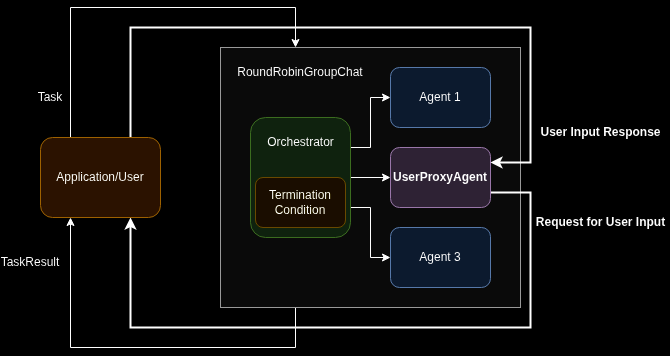

There are two ways to implement this approach:
- Set the maximum number of turns so that the team always stops after the specified number of turns.
- Use termination conditions such as `TextMentionTermination` and `HandoffTermination` to allow the team to decide when to stop and give control back, given the team’s internal state.

Here is an example of how to use `max_turns` in a `RoundRobinGroupChat` for a poetry generation task with a maximum of 1 turn:



In [ ]:
# Create the agents.
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o-mini",
    api_key=os.environ["OPENAI_API_KEY"],
)
assistant = agent.AssistantAgent("assistant", model_client=model_client)
# Create the team setting a maximum number of turns to 1.
task = "Write a 4-line poem about the ocean."
while True:
    # Run the conversation and stream to the console.
    stream = team.run_stream(task=task)
    # Use asyncio.run(...) when running in a script.
    await ui.Console(stream)
    # Get the user response.
    task = input("Enter your feedback (type 'exit' to leave): ")
    if task.lower().strip() == "exit":
        break
await model_client.close()

---------- TextMessage (user) ----------
Write a 4-line poem about the ocean.
---------- TextMessage (Analyst) ----------
The ocean’s whisper, deep and wide,  
Secrets in its endless tide,  
Crashing waves in dance so free,  
A timeless song of mystery.
---------- TextMessage (Reviewer) ----------
A lovely and evocative poem capturing the ocean's vastness and mystery. To strengthen the imagery, consider incorporating more sensory details or vivid metaphors.
---------- TextMessage (Analyst) ----------
Thank you for the positive feedback. Incorporating sensory details or vivid metaphors could indeed enrich the imagery—perhaps references to the scent of salt air, the shimmer of sunlight on waves, or the roar of the deep would make the poem more immersive.
---------- TextMessage (Reviewer) ----------
The response is thoughtful and offers constructive suggestions to deepen the poem’s imagery. To enhance clarity, specifying particular sensory details or metaphors could make the guidance more

### Using termination condition
- `HandoffTermination` is a specialized termination condition that stops a team's execution specifically when an agent sends a HandoffMessage. Unlike general limits (like `max_turns`), this allows an AssistantAgent to dynamically signal when it lacks the relevant tools or information to continue.

- When an agent reaches a dead end or requires external input, it triggers a handoff, transferring control back to the user. This effectively pauses the automated workflow at a logical junction, allowing for manual intervention or the provision of missing data before the task proceeds further.

In [ ]:
# Create an OpenAI model client.
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    api_key=os.environ["OPENAI_API_KEY"],
)

# Create a lazy assistant agent that always hands off to the user.
lazy_agent = agent.AssistantAgent(
    "lazy_assistant",
    model_client=model_client,
    handoffs=[base.Handoff(target="user", message="Transfer to user.")],
    system_message="If you cannot complete the task, transfer to user. Otherwise, when finished, respond with 'TERMINATE'.",
)

# Define a termination condition that checks for handoff messages.
handoff_termination = conditions.HandoffTermination(target="user")
# Define a termination condition that checks for a specific text mention.
text_termination = conditions.TextMentionTermination("TERMINATE")

# Create a single-agent team with the lazy assistant and both termination conditions.
lazy_agent_team = teams.RoundRobinGroupChat(
    [lazy_agent], termination_condition=handoff_termination | text_termination
)

# Run the team and stream to the console.
task = "What is the weather in New York?"
await ui.Console(lazy_agent_team.run_stream(task=task), output_stats=True)

The team stopped due to the handoff message was detected. Let’s continue the team by providing the information the agent needs.

In [ ]:
await ui.Console(
    lazy_agent_team.run_stream(task="The weather in New York is sunny.")
)

The team continued after the user provided the information.



## Termination

AgentChat uses the `TerminationCondition` base class to manage when a team's execution should stop.
- Mechanism: It evaluates recent agent events or messages, returning a StopMessage to terminate the run or `None` to continue.
- State Management: Conditions are stateful and reset automatically after each `run()` or `run_stream()`. If reused manually, you must call `reset()`.
- Flexibility: You can combine multiple conditions using AND (`&`) and OR (`|`) operators to create complex exit logic.

To show the working of the termination conditions. The cell below consists of two agents:
- a primary agent responsible for text generation
- a critic agent that reviews and provides feedback on the generated text.

In [ ]:
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    temperature=1,
    api_key=os.environ["OPENAI_API_KEY"],
)

# Create the primary agent.
primary_agent = agent.AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = agent.AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="Provide constructive feedback for every message. Respond with 'APPROVE' to when your feedbacks are addressed.",
)

Termination conditions automatically reset after each run or run_stream call, allowing the team to resume its conversation from where it left off.

In [ ]:
max_msg_termination = conditions.MaxMessageTermination(max_messages=3)
round_robin_team = teams.RoundRobinGroupChat(
    [primary_agent, critic_agent], termination_condition=max_msg_termination
)

# Use asyncio.run(...) if you are running this script as a standalone script.
await ui.Console(
    round_robin_team.run_stream(
        task="Write a unique, Haiku about the weather in Paris"
    )
)

The conversation stopped after reaching the maximum message limit. Since the primary agent didn’t get to respond to the feedback, let’s continue the conversation.



In [ ]:
await ui.Console(round_robin_team.run_stream())

## Managing State

We can get the state of an agent by calling `save_state()` method on an AssistantAgent.



In [ ]:
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    api_key=os.environ["OPENAI_API_KEY"],
)

assistant_agent = agent.AssistantAgent(
    name="assistant_agent",
    system_message="You are a helpful assistant",
    model_client=model_client,
)

# Use asyncio.run(...) when running in a script.
response = await assistant_agent.on_messages(
    [
        msg.TextMessage(
            content="Write a 3 line poem on lake tangayika", source="user"
        )
    ],
    autogen_core.CancellationToken(),
)
print(response.chat_message)
await model_client.close()

The state can be saved by using the command below

In [ ]:
agent_state = await assistant_agent.save_state()
print(agent_state)

## Saving and Loading Teams

In [ ]:
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    api_key=os.environ["OPENAI_API_KEY"],
)

# Define a team.
assistant_agent = agent.AssistantAgent(
    name="assistant_agent",
    system_message="You are a helpful assistant",
    model_client=model_client,
)
agent_team = teams.RoundRobinGroupChat(
    [assistant_agent],
    termination_condition=conditions.MaxMessageTermination(max_messages=2),
)

# Run the team and stream messages to the console.
stream = agent_team.run_stream(
    task="Write a beautiful poem 3-line about lake tangayika"
)

# Use asyncio.run(...) when running in a script.
await ui.Console(stream)

# Save the state of the agent team.
team_state = await agent_team.save_state()

If we reset the team (simulating instantiation of the team), and ask the question What was the last line of the poem you wrote?, we see that the team is unable to accomplish this as there is no reference to the previous run.

In [ ]:
await agent_team.reset()
stream = agent_team.run_stream(
    task="What was the last line of the poem you wrote?"
)
await ui.Console(stream)

Next, we load the state of the team and ask the same question. We see that the team is able to accurately return the last line of the poem it wrote.



In [ ]:
print(team_state)

# Load team state.
await agent_team.load_state(team_state)
stream = agent_team.run_stream(
    task="What was the last line of the poem you wrote?"
)
await ui.Console(stream)